In [2]:
#All libraries import here
import torch
import torch.nn as nn
import torch.optim as optim
import requests
import json
import pandas as pd
import datetime as dt
import time
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [12]:
import yfinance as yf

spy = yf.download(
    "SPY",
    start="2014-01-01",
    end="2026-09-01",
    auto_adjust=False,
    progress=False
)

spy.head()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY,SPY
Date,,,,,,
2014-01-02,148.198471,182.919998,184.070007,182.479996,183.979996,119636900
2014-01-03,148.174133,182.889999,183.600006,182.630005,183.229996,81390600
2014-01-06,147.744781,182.360001,183.559998,182.080002,183.490005,108028200
2014-01-07,148.652145,183.479996,183.789993,182.949997,183.089996,86144200
2014-01-08,148.684540,183.520004,183.830002,182.889999,183.449997,96582300


In [14]:
spy.to_csv("SPY_daily_raw.csv")

In [19]:
qqq = yf.download(
    "QQQ",
    start="2014-01-01",
    end="2026-09-01",
    auto_adjust=False,
    progress=False
)

qqq.to_csv("QQQ_daily_raw.csv")

qqq.head()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,QQQ,QQQ,QQQ,QQQ,QQQ,QQQ
Date,,,,,,
2014-01-02,78.956886,87.269997,87.580002,87.019997,87.550003,29177500
2014-01-03,78.386887,86.639999,87.349998,86.620003,87.269997,35723700
2014-01-06,78.097351,86.320000,86.760002,86.000000,86.660004,32073100
2014-01-07,78.821144,87.120003,87.250000,86.559998,86.720001,25860600
2014-01-08,78.993042,87.309998,87.550003,86.949997,87.139999,27197400


In [21]:
vix = yf.download(
    "^VIX",
    start="2014-01-01",
    end="2026-09-01",
    auto_adjust=False,
    progress=False
)

vix.to_csv("VIX_daily_raw.csv")

vix.head()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,^VIX,^VIX,^VIX,^VIX,^VIX,^VIX
Date,,,,,,
2014-01-02,14.23,14.23,14.59,14.00,14.32,0
2014-01-03,13.76,13.76,14.22,13.57,14.06,0
2014-01-06,13.55,13.55,14.00,13.22,13.41,0
2014-01-07,12.92,12.92,13.28,12.16,12.38,0
2014-01-08,12.87,12.87,13.24,12.86,13.04,0


# Data preprocessing

In [23]:

# ============================================================
# 1. Clean yfinance column structure
# ============================================================

def clean_yfinance_data(data, ticker):
    """
    Convert yfinance output to ordinary OHLCV columns.
    Works with both single-level and MultiIndex columns.
    """
    data = data.copy()

    if isinstance(data.columns, pd.MultiIndex):
        if ticker in data.columns.get_level_values(-1):
            data = data.xs(
                ticker,
                axis=1,
                level=-1
            )
        else:
            data.columns = data.columns.get_level_values(0)

    data.index = pd.to_datetime(data.index)
    data.index.name = "Date"

    data = data[
        ~data.index.duplicated(keep="first")
    ].sort_index()

    return data


spy = clean_yfinance_data(spy, "SPY")
qqq = clean_yfinance_data(qqq, "QQQ")
vix = clean_yfinance_data(vix, "^VIX")


# ============================================================
# 2. Inspect the raw datasets
# ============================================================

print("SPY:")
print(spy.head())
print(spy.shape)
print(spy.index.min(), spy.index.max())

print("\nQQQ:")
print(qqq.head())
print(qqq.shape)
print(qqq.index.min(), qqq.index.max())

print("\nVIX:")
print(vix.head())
print(vix.shape)
print(vix.index.min(), vix.index.max())


# ============================================================
# 3. Select and rename the required series
# ============================================================

spy_data = spy[
    ["Open", "High", "Low", "Close", "Adj Close", "Volume"]
].copy()

qqq_data = qqq[
    ["Adj Close"]
].rename(
    columns={"Adj Close": "QQQ_Adj_Close"}
)

vix_data = vix[
    ["Close"]
].rename(
    columns={"Close": "VIX_Close"}
)


# ============================================================
# 4. Align all datasets by trading date
# ============================================================

market_data = (
    spy_data
    .join(qqq_data, how="inner")
    .join(vix_data, how="inner")
)

market_data = market_data.dropna().sort_index()


# ============================================================
# 5. Check the aligned dataset
# ============================================================

print("\nAligned dataset:")
print(market_data.head())

print("\nShape:")
print(market_data.shape)

print("\nDate range:")
print(
    market_data.index.min(),
    "to",
    market_data.index.max()
)

print("\nMissing values:")
print(market_data.isna().sum())

print("\nDuplicated dates:")
print(market_data.index.duplicated().sum())

SPY:
Price        Adj Close       Close        High         Low        Open  \
Date                                                                     
2014-01-02  148.198471  182.919998  184.070007  182.479996  183.979996   
2014-01-03  148.174133  182.889999  183.600006  182.630005  183.229996   
2014-01-06  147.744781  182.360001  183.559998  182.080002  183.490005   
2014-01-07  148.652145  183.479996  183.789993  182.949997  183.089996   
2014-01-08  148.684540  183.520004  183.830002  182.889999  183.449997   

Price          Volume  
Date                   
2014-01-02  119636900  
2014-01-03   81390600  
2014-01-06  108028200  
2014-01-07   86144200  
2014-01-08   96582300  
(3184, 6)
2014-01-02 00:00:00 2026-08-31 00:00:00

QQQ:
Price       Adj Close      Close       High        Low       Open    Volume
Date                                                                       
2014-01-02  78.956886  87.269997  87.580002  87.019997  87.550003  29177500
2014-01-03  78.386887  8

In [25]:
market_data

Price,Open,High,Low,Close,Adj Close,Volume,QQQ_Adj_Close,VIX_Close
Date,,,,,,,,
2014-01-02,183.979996,184.070007,182.479996,182.919998,148.198471,119636900,78.956886,14.23
2014-01-03,183.229996,183.600006,182.630005,182.889999,148.174133,81390600,78.386887,13.76
2014-01-06,183.490005,183.559998,182.080002,182.360001,147.744781,108028200,78.097351,13.55
2014-01-07,183.089996,183.789993,182.949997,183.479996,148.652145,86144200,78.821144,12.92
2014-01-08,183.449997,183.830002,182.889999,183.520004,148.684540,96582300,78.993042,12.87
...,...,...,...,...,...,...,...,...
2026-08-25,766.159973,766.780029,763.049988,765.909973,765.909973,27422300,710.719971,15.45
2026-08-26,764.729980,767.349976,763.929993,766.080017,766.080017,28751600,711.369995,15.21
2026-08-27,768.500000,772.359985,767.159973,771.099976,771.099976,34557100,721.109985,14.51


In [27]:
# Remove the inherited yfinance column-axis label
market_data.columns.name = None

# Save the aligned but unprocessed market dataset
market_data.to_csv(
    "SPY_QQQ_VIX_aligned_raw.csv",
    index_label="Date"
)

print(
    "Saved aligned market data to: "
    "SPY_QQQ_VIX_aligned_raw.csv"
)

print("Shape:", market_data.shape)
print(
    "Date range:",
    market_data.index.min(),
    "to",
    market_data.index.max()
)

Saved aligned market data to: SPY_QQQ_VIX_aligned_raw.csv
Shape: (3184, 8)
Date range: 2014-01-02 00:00:00 to 2026-08-31 00:00:00


In [33]:
# ============================================================
# SPY FEATURE CONSTRUCTION
# Following the current Bitcoin preprocessing structure
# ============================================================

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. Start from the aligned raw dataset
# ------------------------------------------------------------

df = market_data.copy()
df.columns.name = None
df = df.sort_index()


# ------------------------------------------------------------
# 2. Outcome variable: SPY log return
# Calculated using dividend- and split-adjusted prices
# ------------------------------------------------------------

df["log_return"] = np.log(
    df["Adj Close"]
    / df["Adj Close"].shift(1)
)


# ------------------------------------------------------------
# 3. Related-market predictor: QQQ log return
# Similar to ETH_LogReturns in the Bitcoin dataset
# ------------------------------------------------------------

df["QQQ_LogReturns"] = np.log(
    df["QQQ_Adj_Close"]
    / df["QQQ_Adj_Close"].shift(1)
)


# ------------------------------------------------------------
# 4. Market-uncertainty predictor: VIX log change
# ------------------------------------------------------------

df["VIX_LogChange"] = np.log(
    df["VIX_Close"]
    / df["VIX_Close"].shift(1)
)


# ------------------------------------------------------------
# 5. Parkinson volatility
# Calculated from the daily SPY high-low range
# ------------------------------------------------------------

df["Volatility"] = (
    np.log(df["High"])
    - np.log(df["Low"])
) ** 2 / (4 * np.log(2))


# ------------------------------------------------------------
# 6. RSI(14)
# Relative Strength Index calculated from SPY closing prices
# ------------------------------------------------------------

close_change = df["Close"].diff()

gain = close_change.clip(lower=0)
loss = -close_change.clip(upper=0)

average_gain = gain.rolling(
    window=14
).mean()

average_loss = loss.rolling(
    window=14
).mean()

relative_strength = (
    average_gain / average_loss
)

df["RSI_14"] = (
    100
    - 100 / (1 + relative_strength)
)


# ------------------------------------------------------------
# 7. ATR(14)
# Average True Range calculated from SPY OHLC prices
# ------------------------------------------------------------

high_low = (
    df["High"] - df["Low"]
)

high_previous_close = np.abs(
    df["High"]
    - df["Close"].shift(1)
)

low_previous_close = np.abs(
    df["Low"]
    - df["Close"].shift(1)
)

true_range = pd.concat(
    [
        high_low,
        high_previous_close,
        low_previous_close
    ],
    axis=1
).max(axis=1)

df["ATR_14"] = true_range.rolling(
    window=14
).mean()


# ------------------------------------------------------------
# 8. SPY trading-volume log change
# ------------------------------------------------------------

df["Volume_LogChange"] = np.log(
    df["Volume"]
    / df["Volume"].shift(1)
)


# ------------------------------------------------------------
# 9. Define the predictor columns
# ------------------------------------------------------------

feature_cols = [
    "Volatility",
    "RSI_14",
    "ATR_14",
    "QQQ_LogReturns",
    "VIX_LogChange",
    "Volume_LogChange"
]


# ------------------------------------------------------------
# 10. Retain only the outcome and predictors
# ------------------------------------------------------------

spy_features = df[
    ["log_return"] + feature_cols
].copy()

spy_features = spy_features.replace(
    [np.inf, -np.inf],
    np.nan
)

# Initial observations are unavailable because RSI and ATR
# require a 14-day rolling window.
spy_features = spy_features.dropna()


# ------------------------------------------------------------
# 11. Save the unscaled feature dataset
# ------------------------------------------------------------

spy_features.to_csv(
    "SPY_features_unscaled.csv",
    index_label="Date"
)

spy_features.head()

,log_return,Volatility,RSI_14,ATR_14,QQQ_LogReturns,VIX_LogChange,Volume_LogChange
Date,,,,,,,
2014-01-23,-0.008227,0.000027,49.406371,1.455000,-0.003385,0.069927,0.771254
2014-01-24,-0.021566,0.000089,36.504730,1.668570,-0.019861,0.275627,0.454229
2014-01-27,-0.004932,0.000065,35.662484,1.734286,-0.009731,-0.040500,-0.143158
2014-01-28,0.005937,0.000016,35.407084,1.724287,-0.000582,-0.097609,-0.492947
2014-01-29,-0.009652,0.000032,31.625999,1.813572,-0.010774,0.093583,0.673357


Full sample: 3170
Training: 2219
Validation: 475
Test: 476


,Variable,Sample,N,Mean,SD,Median,Minimum,Maximum,Skewness,Kurtosis
0,SPY log return,Full sample,3170,0.000516,0.010845,0.000683,-0.115887,0.099863,-0.578102,14.772576
1,SPY log return,Training,2219,0.000420,0.011369,0.000598,-0.115887,0.086731,-0.837198,14.185642
2,SPY log return,Validation,475,0.000826,0.008388,0.000698,-0.029556,0.031015,-0.151465,0.520327
3,SPY log return,Test,476,0.000656,0.010519,0.001000,-0.060327,0.099863,0.841807,20.102005
4,Parkinson volatility,Full sample,3170,0.000070,0.000178,0.000028,0.000001,0.004114,10.701196,162.847405
5,Parkinson volatility,Training,2219,0.000075,0.000179,0.000027,0.000001,0.002816,8.231750,92.032737
6,Parkinson volatility,Validation,475,0.000048,0.000054,0.000030,0.000001,0.000453,3.047036,12.376521
7,Parkinson volatility,Test,476,0.000068,0.000242,0.000028,0.000002,0.004114,12.789244,189.560185
8,RSI (14),Full sample,3170,56.665464,16.104728,57.368914,3.877689,97.676736,-0.080952,-0.454522
9,RSI (14),Training,2219,56.359791,16.290146,56.810913,3.877689,97.186510,-0.041895,-0.455116


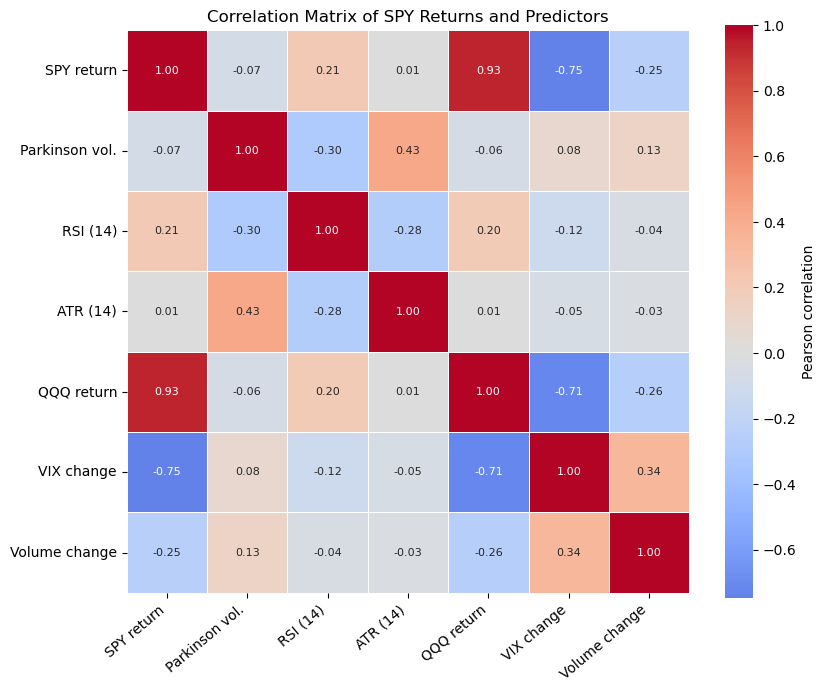

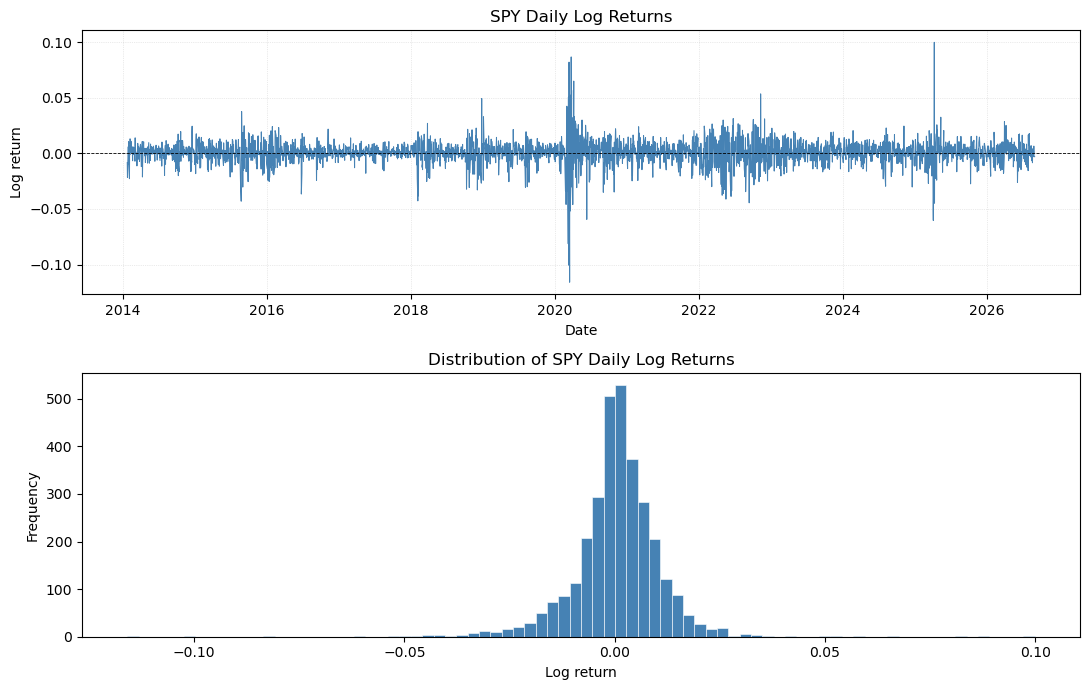

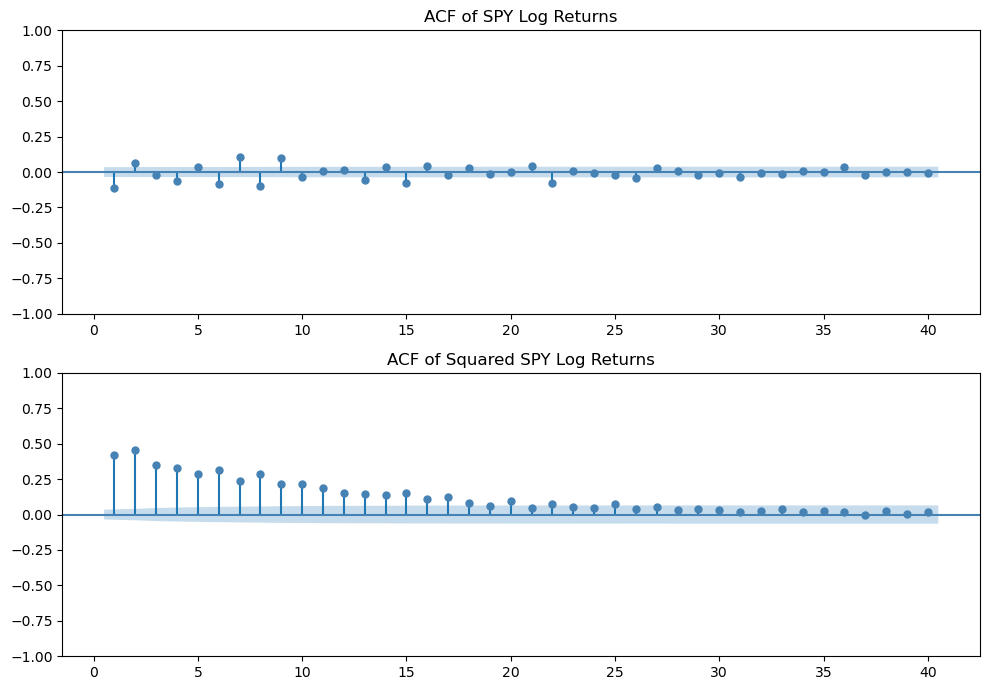


Saved outputs:
SPY_summary_statistics.csv
SPY_correlation_matrix.csv
SPY_correlation_matrix.png
SPY_return_overview.png
SPY_return_acf.png


In [35]:
# ============================================================
# SPY DESCRIPTIVE ANALYSIS
# Uses the unscaled SPY feature dataset
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.graphics.tsaplots import plot_acf


# ------------------------------------------------------------
# 1. Chronological sample boundaries
# ------------------------------------------------------------

number_of_observations = len(spy_features)

train_size = int(
    number_of_observations * 0.70
)

validation_size = int(
    number_of_observations * 0.15
)

test_size = (
    number_of_observations
    - train_size
    - validation_size
)

sample_slices = {
    "Full sample": slice(None),
    "Training": slice(0, train_size),
    "Validation": slice(
        train_size,
        train_size + validation_size
    ),
    "Test": slice(
        train_size + validation_size,
        None
    )
}

print(
    f"Full sample: {number_of_observations}"
)

print(
    f"Training: {train_size}"
)

print(
    f"Validation: {validation_size}"
)

print(
    f"Test: {test_size}"
)


# ------------------------------------------------------------
# 2. Variable labels
# ------------------------------------------------------------

variable_names = {
    "log_return": "SPY log return",
    "Volatility": "Parkinson volatility",
    "RSI_14": "RSI (14)",
    "ATR_14": "ATR (14)",
    "QQQ_LogReturns": "QQQ log return",
    "VIX_LogChange": "VIX log change",
    "Volume_LogChange": "SPY volume log change"
}


# ------------------------------------------------------------
# 3. Summary statistics by sample period
# ------------------------------------------------------------

summary_records = []

for variable, variable_label in variable_names.items():

    for sample_name, sample_slice in sample_slices.items():

        values = (
            spy_features[variable]
            .iloc[sample_slice]
            .dropna()
        )

        summary_records.append({
            "Variable": variable_label,
            "Sample": sample_name,
            "N": len(values),
            "Mean": values.mean(),
            "SD": values.std(),
            "Median": values.median(),
            "Minimum": values.min(),
            "Maximum": values.max(),
            "Skewness": values.skew(),
            "Kurtosis": values.kurt()
        })

summary_statistics = pd.DataFrame(
    summary_records
)

summary_statistics.to_csv(
    "SPY_summary_statistics.csv",
    index=False
)

display(
    summary_statistics.round(6)
)


# ------------------------------------------------------------
# 4. Correlation matrix
# ------------------------------------------------------------

correlation_variables = [
    "log_return",
    "Volatility",
    "RSI_14",
    "ATR_14",
    "QQQ_LogReturns",
    "VIX_LogChange",
    "Volume_LogChange"
]

correlation_matrix = (
    spy_features[correlation_variables]
    .corr()
)

correlation_matrix.to_csv(
    "SPY_correlation_matrix.csv"
)

correlation_labels = [
    "SPY return",
    "Parkinson vol.",
    "RSI (14)",
    "ATR (14)",
    "QQQ return",
    "VIX change",
    "Volume change"
]

plt.figure(
    figsize=(8.5, 7)
)

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    xticklabels=correlation_labels,
    yticklabels=correlation_labels,
    annot_kws={"size": 8},
    cbar_kws={
        "label": "Pearson correlation"
    }
)

plt.title(
    "Correlation Matrix of SPY Returns and Predictors"
)

plt.xticks(
    rotation=40,
    ha="right"
)

plt.yticks(
    rotation=0
)

plt.tight_layout()

plt.savefig(
    "SPY_correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 5. SPY return time series and distribution
# ------------------------------------------------------------

fig, axes = plt.subplots(
    2,
    1,
    figsize=(11, 7)
)

axes[0].plot(
    spy_features.index,
    spy_features["log_return"],
    color="steelblue",
    linewidth=0.75
)

axes[0].axhline(
    0,
    color="black",
    linewidth=0.6,
    linestyle="--"
)

axes[0].set_title(
    "SPY Daily Log Returns"
)

axes[0].set_xlabel("Date")
axes[0].set_ylabel("Log return")

axes[0].grid(
    linestyle=":",
    linewidth=0.5,
    alpha=0.5
)

axes[1].hist(
    spy_features["log_return"],
    bins=80,
    color="steelblue",
    edgecolor="white",
    linewidth=0.4
)

axes[1].set_title(
    "Distribution of SPY Daily Log Returns"
)

axes[1].set_xlabel("Log return")
axes[1].set_ylabel("Frequency")

fig.tight_layout()

fig.savefig(
    "SPY_return_overview.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 6. ACF of returns and squared returns
# ------------------------------------------------------------

fig, axes = plt.subplots(
    2,
    1,
    figsize=(10, 7)
)

plot_acf(
    spy_features["log_return"],
    lags=40,
    ax=axes[0],
    color="steelblue",
    zero=False
)

axes[0].set_title(
    "ACF of SPY Log Returns"
)

plot_acf(
    spy_features["log_return"] ** 2,
    lags=40,
    ax=axes[1],
    color="steelblue",
    zero=False
)

axes[1].set_title(
    "ACF of Squared SPY Log Returns"
)

fig.tight_layout()

fig.savefig(
    "SPY_return_acf.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 7. Saved-output confirmation
# ------------------------------------------------------------

print("\nSaved outputs:")

print("SPY_summary_statistics.csv")
print("SPY_correlation_matrix.csv")
print("SPY_correlation_matrix.png")
print("SPY_return_overview.png")
print("SPY_return_acf.png")

,Sample,Observations,Start,End
0,Training,2219,2014-01-23,2022-11-11
1,Validation,475,2022-11-14,2024-10-04
2,Test,476,2024-10-07,2026-08-31


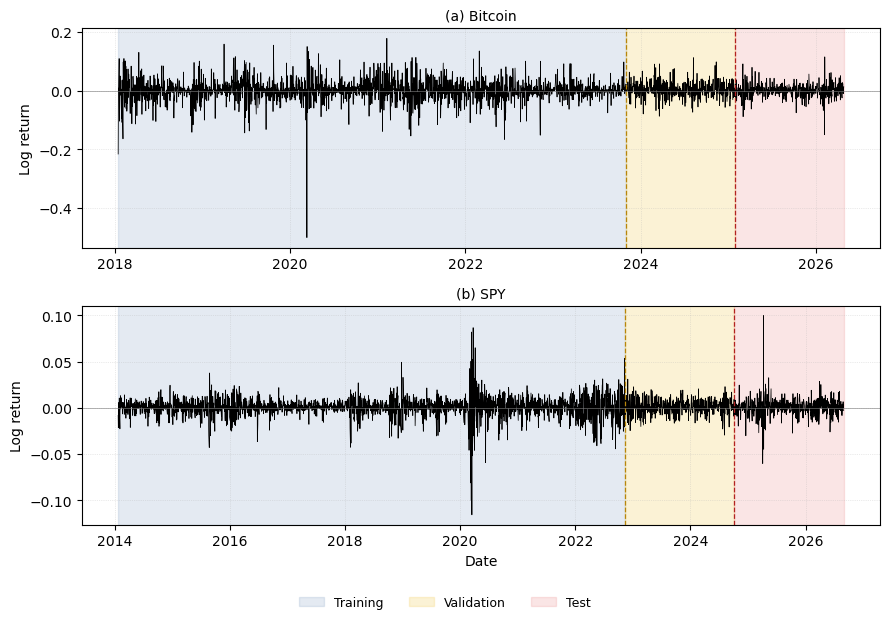

Scaled SPY data saved to: /Users/miaomiaochen/SPY_features_scaled.csv
SPY scaler saved to: /Users/miaomiaochen/SPY_feature_scaler.pkl
Combined plot saved to: /Users/miaomiaochen/Bitcoin_SPY_sample_periods.png


In [37]:
# ============================================================
# SPY: CHRONOLOGICAL SPLIT, TRAIN-ONLY SCALING,
# AND BITCOIN–SPY SAMPLE-SPLIT PLOT
# ============================================================

from pathlib import Path
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.preprocessing import MinMaxScaler


# ------------------------------------------------------------
# 1. File paths
# ------------------------------------------------------------

HOME_DIR = Path.home()

SPY_INPUT_PATH = HOME_DIR / "SPY_features_unscaled.csv"

BTC_INPUT_PATH = (
    HOME_DIR
    / "Desktop"
    / "PhD program"
    / "Project 1"
    / "BTCUSDT_full_features.csv"
)

SPY_OUTPUT_PATH = HOME_DIR / "SPY_features_scaled.csv"
SCALER_OUTPUT_PATH = HOME_DIR / "SPY_feature_scaler.pkl"
PLOT_OUTPUT_PATH = HOME_DIR / "Bitcoin_SPY_sample_periods.png"


# ------------------------------------------------------------
# 2. Load SPY data
# ------------------------------------------------------------

spy_data = pd.read_csv(
    SPY_INPUT_PATH,
    parse_dates=["Date"]
)

spy_data = (
    spy_data
    .sort_values("Date")
    .drop_duplicates(subset="Date")
    .set_index("Date")
)

# Remove observations with unavailable features
spy_data = spy_data.dropna().copy()


# ------------------------------------------------------------
# 3. Define the response and predictor variables
# ------------------------------------------------------------

response_column = "log_return"

feature_columns = [
    "Volatility",
    "RSI_14",
    "ATR_14",
    "QQQ_LogReturns",
    "VIX_LogChange",
    "Volume_LogChange",
]

required_columns = [response_column] + feature_columns

missing_columns = [
    column
    for column in required_columns
    if column not in spy_data.columns
]

if missing_columns:
    raise ValueError(
        "Missing SPY columns: "
        + ", ".join(missing_columns)
    )


# ------------------------------------------------------------
# 4. Chronological 70%–15%–15% split
# ------------------------------------------------------------

number_of_observations = len(spy_data)

train_end = int(number_of_observations * 0.70)
validation_end = int(number_of_observations * 0.85)

spy_train = spy_data.iloc[:train_end].copy()

spy_validation = spy_data.iloc[
    train_end:validation_end
].copy()

spy_test = spy_data.iloc[
    validation_end:
].copy()


# ------------------------------------------------------------
# 5. Fit the scaler using training predictors only
# ------------------------------------------------------------

spy_scaler = MinMaxScaler(
    feature_range=(0, 1)
)

spy_scaler.fit(
    spy_train[feature_columns]
)

spy_scaled = spy_data.copy()

spy_scaled[feature_columns] = (
    spy_scaler.transform(
        spy_data[feature_columns]
    )
)

# The response remains in its original log-return scale
spy_scaled[response_column] = (
    spy_data[response_column]
)


# ------------------------------------------------------------
# 6. Create scaled datasets for modelling
# ------------------------------------------------------------

spy_train_scaled = spy_scaled.iloc[
    :train_end
].copy()

spy_validation_scaled = spy_scaled.iloc[
    train_end:validation_end
].copy()

spy_test_scaled = spy_scaled.iloc[
    validation_end:
].copy()


# ------------------------------------------------------------
# 7. Save the scaled dataset and fitted scaler
# ------------------------------------------------------------

spy_scaled.to_csv(
    SPY_OUTPUT_PATH,
    index_label="Date"
)

joblib.dump(
    spy_scaler,
    SCALER_OUTPUT_PATH
)


# ------------------------------------------------------------
# 8. Display the SPY split information
# ------------------------------------------------------------

spy_split_summary = pd.DataFrame({
    "Sample": [
        "Training",
        "Validation",
        "Test"
    ],
    "Observations": [
        len(spy_train_scaled),
        len(spy_validation_scaled),
        len(spy_test_scaled)
    ],
    "Start": [
        spy_train_scaled.index.min(),
        spy_validation_scaled.index.min(),
        spy_test_scaled.index.min()
    ],
    "End": [
        spy_train_scaled.index.max(),
        spy_validation_scaled.index.max(),
        spy_test_scaled.index.max()
    ]
})

display(spy_split_summary)


# ------------------------------------------------------------
# 9. Load Bitcoin returns
# ------------------------------------------------------------

bitcoin_data = pd.read_csv(
    BTC_INPUT_PATH,
    parse_dates=["Date"]
)

bitcoin_data = (
    bitcoin_data
    .sort_values("Date")
    .drop_duplicates(subset="Date")
    .set_index("Date")
)

bitcoin_data = bitcoin_data[
    ["log_return"]
].dropna()


# ------------------------------------------------------------
# 10. Determine the Bitcoin split boundaries
# ------------------------------------------------------------

bitcoin_number_of_observations = len(
    bitcoin_data
)

bitcoin_train_end = int(
    bitcoin_number_of_observations * 0.70
)

bitcoin_validation_end = int(
    bitcoin_number_of_observations * 0.85
)


# ------------------------------------------------------------
# 11. Function for plotting the sample periods
# ------------------------------------------------------------

def plot_sample_periods(
    axis,
    data,
    train_boundary,
    validation_boundary,
    title
):
    dates = data.index
    returns = data["log_return"]

    axis.plot(
        dates,
        returns,
        color="black",
        linewidth=0.55
    )

    # Training period
    axis.axvspan(
        dates[0],
        dates[train_boundary - 1],
        color="#4C78A8",
        alpha=0.15,
        label="Training"
    )

    # Validation period
    axis.axvspan(
        dates[train_boundary],
        dates[validation_boundary - 1],
        color="#F2CF5B",
        alpha=0.25,
        label="Validation"
    )

    # Test period
    axis.axvspan(
        dates[validation_boundary],
        dates[-1],
        color="#E45756",
        alpha=0.15,
        label="Test"
    )

    axis.axvline(
        dates[train_boundary],
        color="#B8860B",
        linestyle="--",
        linewidth=0.9
    )

    axis.axvline(
        dates[validation_boundary],
        color="#B22222",
        linestyle="--",
        linewidth=0.9
    )

    axis.axhline(
        0,
        color="grey",
        linewidth=0.6,
        alpha=0.7
    )

    axis.set_title(
        title,
        fontsize=10
    )

    axis.set_ylabel(
        "Log return"
    )

    axis.grid(
        True,
        linestyle=":",
        linewidth=0.5,
        alpha=0.5
    )

    axis.xaxis.set_major_locator(
        mdates.YearLocator(2)
    )

    axis.xaxis.set_major_formatter(
        mdates.DateFormatter("%Y")
    )


# ------------------------------------------------------------
# 12. Create the combined Bitcoin–SPY plot
# ------------------------------------------------------------

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(9.0, 6.2)
)

plot_sample_periods(
    axis=axes[0],
    data=bitcoin_data,
    train_boundary=bitcoin_train_end,
    validation_boundary=bitcoin_validation_end,
    title="(a) Bitcoin"
)

plot_sample_periods(
    axis=axes[1],
    data=spy_data,
    train_boundary=train_end,
    validation_boundary=validation_end,
    title="(b) SPY"
)

axes[1].set_xlabel("Date")

# Use one common legend
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.01),
    ncol=3,
    frameon=False,
    fontsize=9
)

fig.tight_layout(
    rect=[0, 0.05, 1, 1]
)

fig.savefig(
    PLOT_OUTPUT_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Scaled SPY data saved to: {SPY_OUTPUT_PATH}")
print(f"SPY scaler saved to: {SCALER_OUTPUT_PATH}")
print(f"Combined plot saved to: {PLOT_OUTPUT_PATH}")